## Python 

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

os.makedirs("outputs", exist_ok=True)

## P1 — Load, Clean & Merge 


In [17]:
# Load CSV files
assessments = pd.read_csv("assessments.csv")
courses = pd.read_csv("courses.csv")


# Check numeric data types
print("Score datatype:", assessments["score"].dtype)
print("Attendance datatype:", assessments["attendance_pct"].dtype)

# Remove exact duplicate rows
assessments = assessments.drop_duplicates()


# Merge assessments with courses
merged = assessments.merge(
    courses,
    on="course_id",
    how="left"
)

# Check rows and unmatched departments
print("Number of rows:", len(merged))
print("Unmatched department values:", merged["department"].isna().sum())

# Display merged data
print(merged)


Score datatype: int64
Attendance datatype: int64
Number of rows: 12
Unmatched department values: 0
    assessment_id month course_id    batch  score  attendance_pct   course  \
0               1   Jan        C1  Morning     72              90    Excel   
1               2   Jan        C2  Evening     45              70  PowerBI   
2               3   Jan        C3  Morning     65              85      SQL   
3               4   Jan        C4  Weekend     38              60   Python   
4               5   Feb        C1  Evening     80              95    Excel   
5               6   Feb        C2  Weekend     55              80  PowerBI   
6               7   Feb        C3  Morning     48              75      SQL   
7               8   Feb        C4  Evening     68              88   Python   
8               9   Mar        C1  Weekend     90              98    Excel   
9              10   Mar        C2  Morning     60              82  PowerBI   
10             11   Mar        C3  Evening 

## P2 — Derived Field & Department Analysi

In [18]:
##1. Create pass_flag
merged["pass_flag"] = (merged["score"] >= 50).astype(int)

##2. Department summary


department_group = merged.groupby("department")

total_assessments = department_group["score"].count()
passing_count = department_group["pass_flag"].sum()

pass_rate = (passing_count / total_assessments) * 100

department_summary = pd.DataFrame({
    "department": total_assessments.index,
    "total_assessments": total_assessments.values,
    "passing_count": passing_count.values,
    "pass_rate": pass_rate.values
})

print(department_summary)

##3. Course with lowest pass rate


course_group = merged.groupby("course")

passing_count = course_group["pass_flag"].sum()
total_assessments = course_group["score"].count()

pass_rate = (passing_count / total_assessments) * 100

course_summary = pd.DataFrame({
    "passing_count": passing_count,
    "total_assessments": total_assessments,
    "pass_rate": pass_rate
})

print(course_summary)

## Lowest pass-rate course

course_summary = course_summary.sort_values("pass_rate")

lowest_course = course_summary.iloc[0]

print("\nCourse with lowest pass rate:")
print("Course:", lowest_course.name)
print("Passing:", int(lowest_course["passing_count"]))
print("Total:", int(lowest_course["total_assessments"]))
print("Pass Rate:", lowest_course["pass_rate"])

   department  total_assessments  passing_count  pass_rate
0    Business                  6              5  83.333333
1  Technology                  6              3  50.000000
         passing_count  total_assessments   pass_rate
course                                               
Excel                3                  3  100.000000
PowerBI              2                  3   66.666667
Python               1                  3   33.333333
SQL                  2                  3   66.666667

Course with lowest pass rate:
Course: Python
Passing: 1
Total: 3
Pass Rate: 33.33333333333333


## P3 — Monthly Average Score Chart

In [19]:
# Set month order
month_order = ["Jan", "Feb", "Mar"]

merged["month"] = pd.Categorical(
    merged["month"],
    categories=month_order,
    ordered=True
)

# Calculate monthly average score
monthly_avg = merged.groupby(
    "month",
    observed=False
)["score"].mean().reset_index()

print(monthly_avg)

  month  score
0   Jan  55.00
1   Feb  62.75
2   Mar  66.75


**Bar chart**

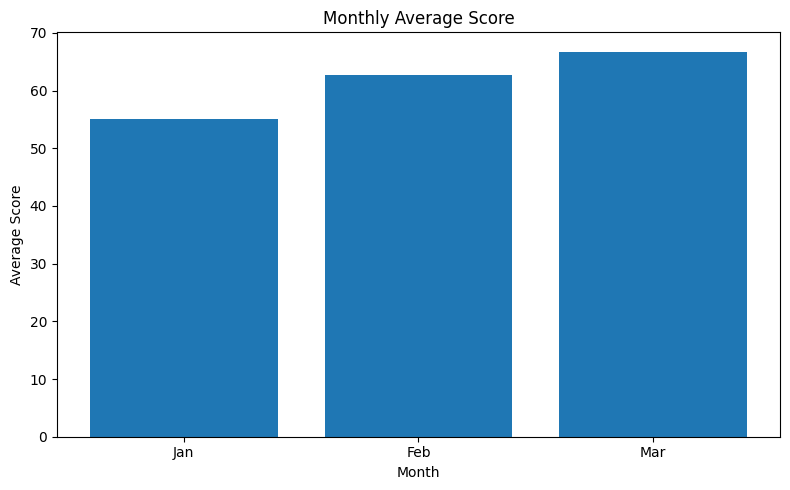

In [20]:
plt.figure(figsize=(8, 5))

plt.bar(
    monthly_avg["month"],
    monthly_avg["score"]
)

plt.title("Monthly Average Score")
plt.xlabel("Month")
plt.ylabel("Average Score")

plt.tight_layout()

plt.savefig("outputs/python_chart.png")
plt.show()

In [21]:
# Export clean merged data
merged.to_csv(
    "outputs/clean_data.csv",
    index=False
)

# Export department summary
department_summary.to_csv(
    "outputs/python_summary.csv",
    index=False
)

print("Files exported successfully.")

Files exported successfully.
